# Task 3: Google Play Store Analysis
Objective: Perform a comprehensive data analysis of the Google Play Store ecosystem, including category exploration, pricing trends, and sentiment analysis on user reviews.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)

In [2]:
# Load the main apps dataset
apps_df = pd.read_csv('../data/googleplaystore.csv')
apps_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB


In [3]:
# Inspect the first few rows to see the formatting issues
apps_df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### 2. Data Cleaning
I had to clean the `Installs`, `Price`, `Reviews`, and `Size` columns to convert them from strings to numeric data types for analysis.

In [4]:
# 1. Drop a known erroneous row in the dataset where data is shifted (Category is '1.9')
apps_df = apps_df[apps_df['Category'] != '1.9']

# 2. Clean 'Installs' (remove '+' and ',')
apps_df['Installs'] = apps_df['Installs'].astype(str).str.replace('+', '').str.replace(',', '')
apps_df['Installs'] = pd.to_numeric(apps_df['Installs'], errors='coerce')

# 3. Clean 'Price' (remove '$')
apps_df['Price'] = apps_df['Price'].astype(str).str.replace('$', '')
apps_df['Price'] = pd.to_numeric(apps_df['Price'], errors='coerce')

# 4. Clean 'Reviews'
apps_df['Reviews'] = pd.to_numeric(apps_df['Reviews'], errors='coerce')

# 5. Clean 'Size' (Convert 'M' to millions, 'k' to thousands, handle 'Varies with device')
apps_df['Size'] = apps_df['Size'].astype(str).str.replace('M', 'e6').str.replace('k', 'e3')
apps_df['Size'] = apps_df['Size'].replace('Varies with device', np.nan)
apps_df['Size'] = pd.to_numeric(apps_df['Size'], errors='coerce')

# Check the updated data types
apps_df[['Installs', 'Price', 'Reviews', 'Size']].info()

<class 'pandas.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Installs  10840 non-null  int64  
 1   Price     10840 non-null  float64
 2   Reviews   10840 non-null  int64  
 3   Size      9145 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 423.4 KB


### 3. Category and Ratings Analysis
I decided to analyze which categories have the most apps and explore how app ratings are distributed across the Play Store.

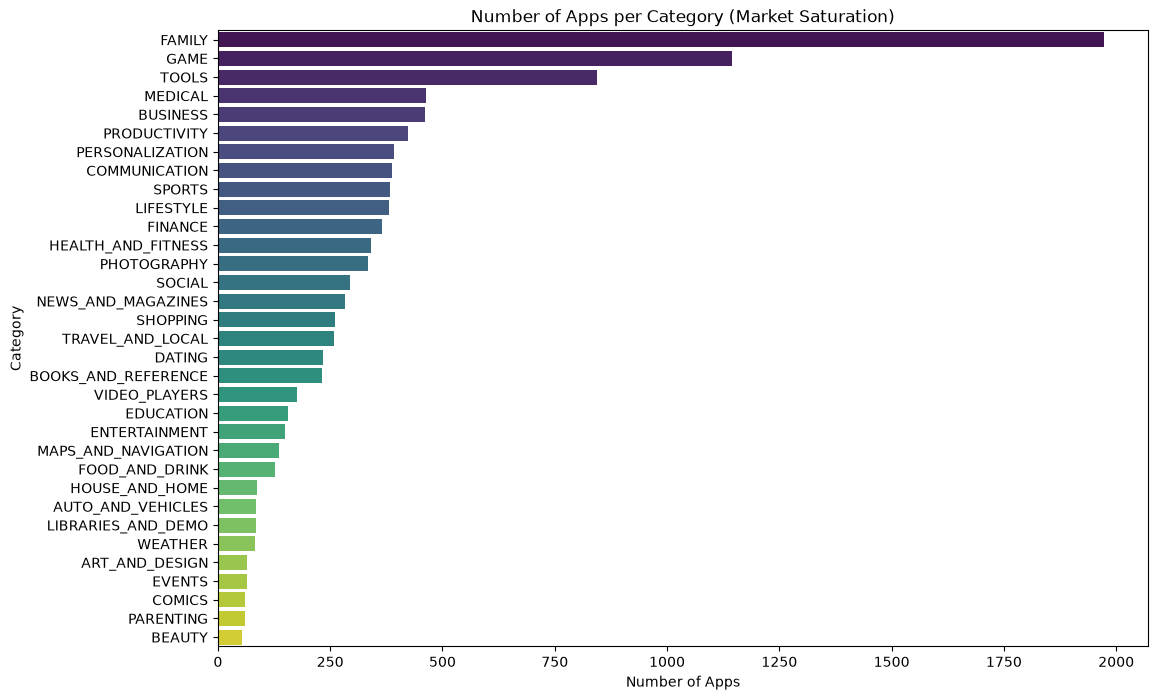

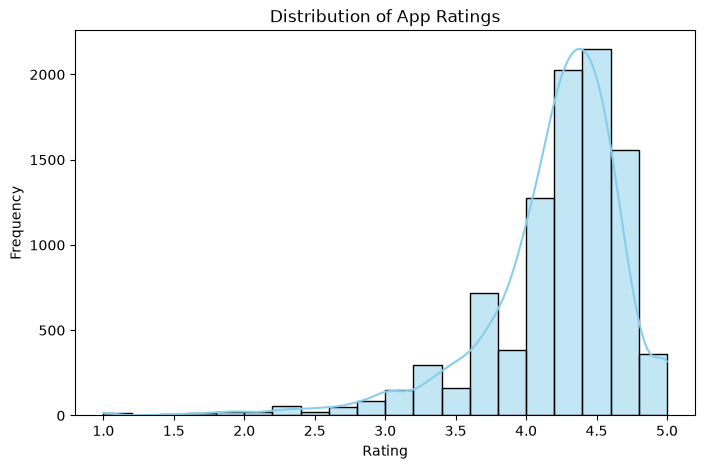

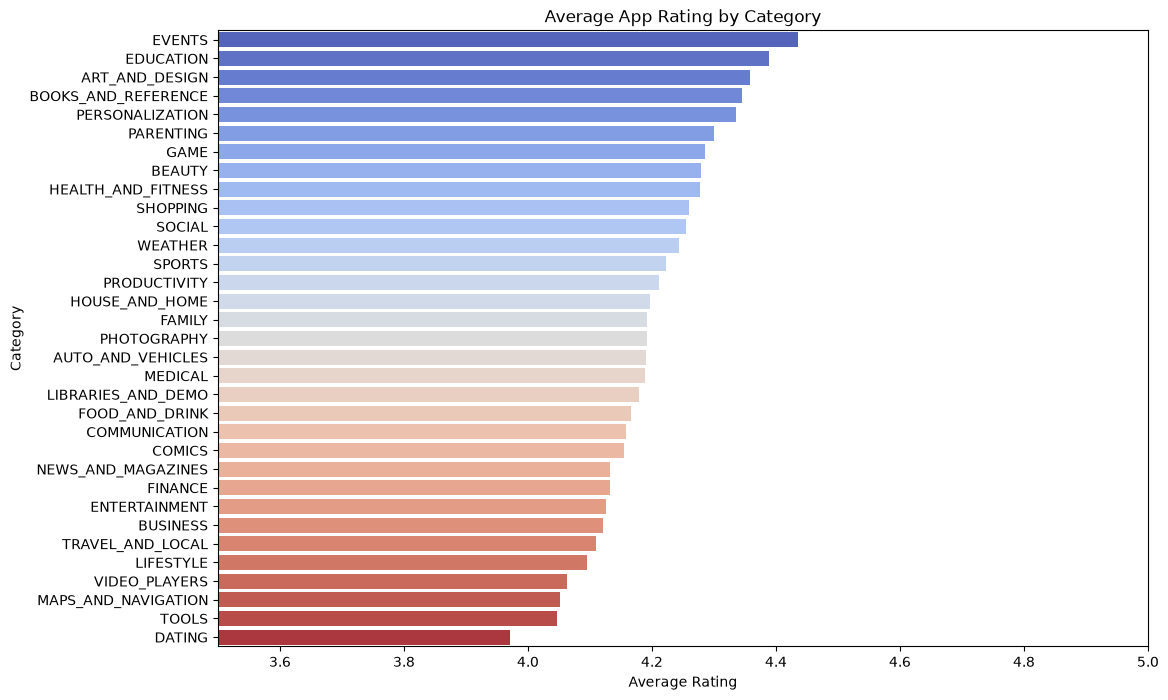

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# 1. Category Analysis (Most saturated categories)
plt.figure(figsize=(12, 8))
category_counts = apps_df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, hue=category_counts.index, palette="viridis", legend=False)
plt.title('Number of Apps per Category (Market Saturation)')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

# 2. Ratings Distribution
plt.figure(figsize=(8, 5))
sns.histplot(apps_df['Rating'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# 3. Average Rating by Category
plt.figure(figsize=(12, 8))
avg_rating = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=avg_rating.values, y=avg_rating.index, hue=avg_rating.index, palette="coolwarm", legend=False)
plt.title('Average App Rating by Category')
plt.xlabel('Average Rating')
plt.ylabel('Category')
plt.xlim(3.5, 5.0)  # Zoom in on the relevant rating range to highlight differences
plt.show()

### 4. Size vs Installs and Pricing Analysis
Now we will look at how the size of an app affects its number of installs using a scatter plot. Then, we will analyze the distribution of Free vs. Paid apps and the price range of paid apps.

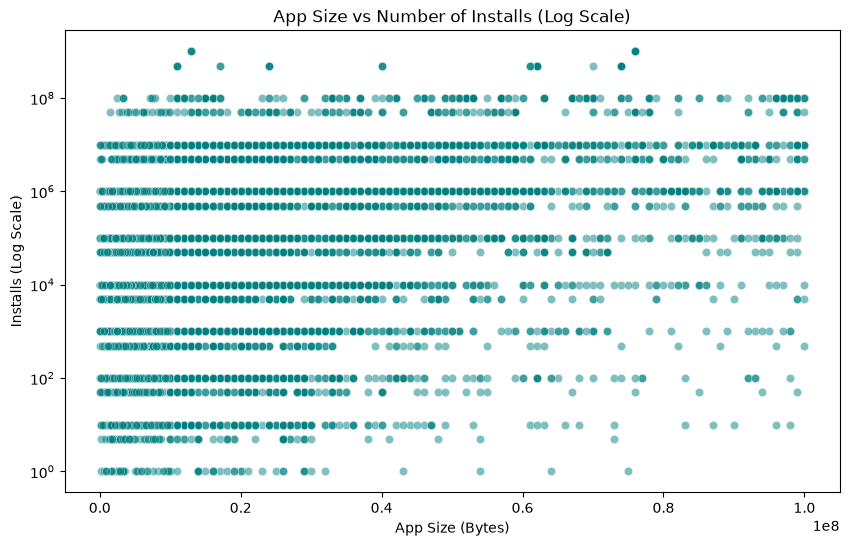

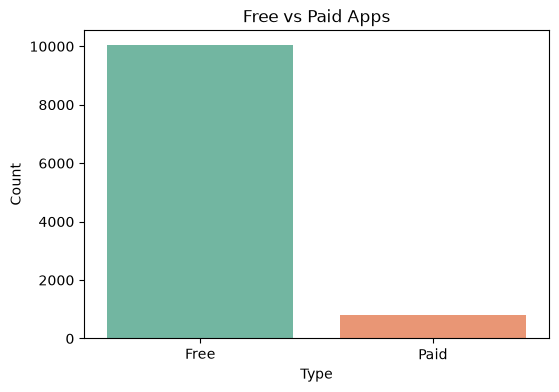

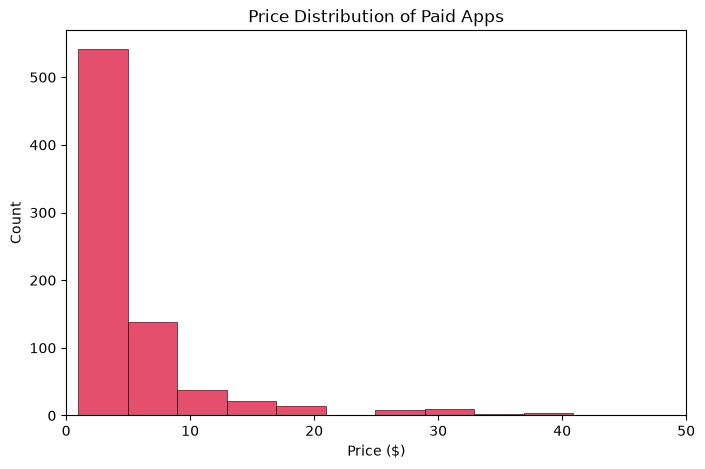

In [6]:
# 1. Size vs Installs (Scatter Plot)
plt.figure(figsize=(10, 6))
# We use a log scale for Installs because the values range from 1 to 1 Billion
sns.scatterplot(x='Size', y='Installs', data=apps_df, alpha=0.5, color='teal')
plt.yscale('log')
plt.title('App Size vs Number of Installs (Log Scale)')
plt.xlabel('App Size (Bytes)')
plt.ylabel('Installs (Log Scale)')
plt.show()

# 2. Free vs Paid Apps Distribution
plt.figure(figsize=(6, 4))
type_counts = apps_df['Type'].value_counts()
sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette="Set2", legend=False)
plt.title('Free vs Paid Apps')
plt.ylabel('Count')
plt.show()

# 3. Price Distribution for Paid Apps
paid_apps = apps_df[apps_df['Type'] == 'Paid']
plt.figure(figsize=(8, 5))
sns.histplot(paid_apps['Price'], bins=100, color='crimson')
plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Count')
# Limiting the x-axis to $50 to focus on standard apps (ignoring extreme outliers like $400 'I am rich' apps)
plt.xlim(0, 50)
plt.show()

### 5. Sentiment Analysis on User Reviews
I decided to merge the apps dataset with the user reviews dataset to see which categories generate the most positive and negative sentiments.

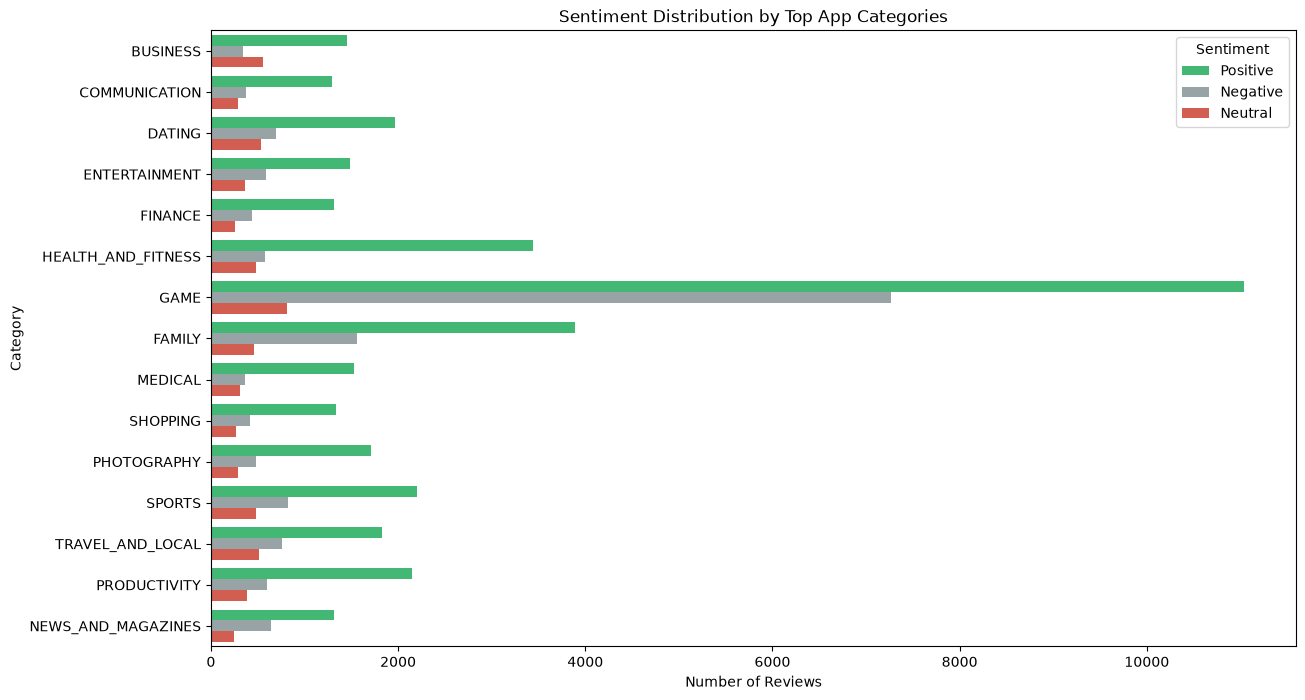

In [7]:
# 1. Load the User Reviews dataset
reviews_df = pd.read_csv('../data/googleplaystore_user_reviews.csv')

# Drop rows where Sentiment is missing
reviews_df = reviews_df.dropna(subset=['Sentiment'])

# 2. Merge datasets (SQL Equivalent: INNER JOIN ON App)
merged_df = pd.merge(apps_df, reviews_df, on='App', how='inner')

# 3. Sentiment by Category (Plotting the top 15 categories by review volume)
plt.figure(figsize=(14, 8))
top_categories = merged_df['Category'].value_counts().head(15).index
filtered_df = merged_df[merged_df['Category'].isin(top_categories)]

sns.countplot(y='Category', hue='Sentiment', data=filtered_df, palette=['#2ecc71', '#95a5a6', '#e74c3c'])
plt.title('Sentiment Distribution by Top App Categories')
plt.xlabel('Number of Reviews')
plt.ylabel('Category')
plt.legend(title='Sentiment')
plt.show()

### Conclusion & Observations
Based on my analysis of the Play Store dataset, I noticed a few interesting things for anyone wanting to launch an app.

First, the Family and Game categories are really crowded. But categories like Events and Education actually get the highest average ratings, so it might be easier to build a satisfied user base there.

Second, almost all apps are free. For the paid ones, the sweet spot is clearly under $4.99. Charging more than that is super rare.

Finally, I noticed that while apps of any size can get some downloads, the ones that hit the 1 Billion+ mark are usually kept under 100MB. Keeping the app size small definitely helps get more installs globally.